1. Import Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time Series
from statsmodels.tsa.arima.model import ARIMA

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

sns.set(style="darkgrid")

2.Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('Walmart.csv')

# Display first 5 rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


3.Data Understanding

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


4. Data Preprocessing

In [5]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Sort values
df = df.sort_values('Date')

# Check missing values
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

5. Aggregate Sales (Important Step)

In [6]:
# Group by Date
sales_data = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

sales_data.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


Sales Trend Visualization

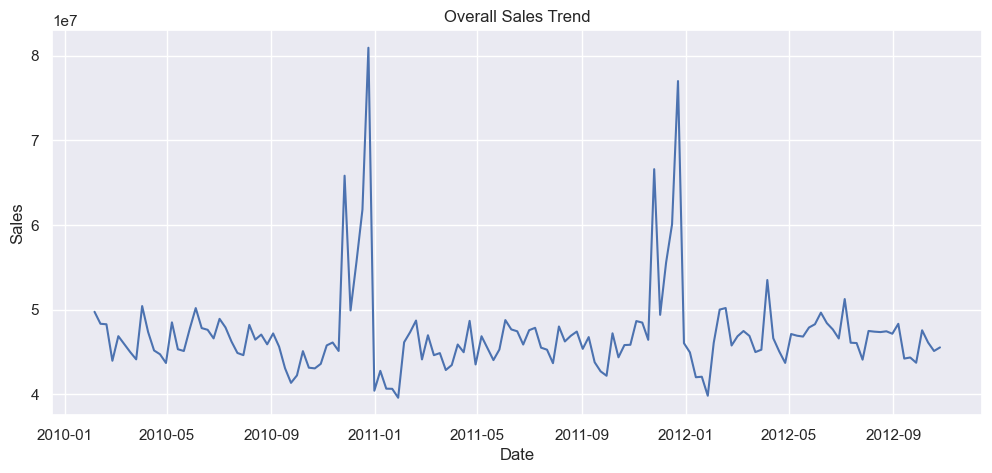

In [7]:
plt.figure(figsize=(12,5))
plt.plot(sales_data['Date'], sales_data['Weekly_Sales'])
plt.title("Overall Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [14]:

total_sales = sales_data['Weekly_Sales'].sum()
avg_sales = sales_data['Weekly_Sales'].mean()
max_sales = sales_data['Weekly_Sales'].max()
min_sales = sales_data['Weekly_Sales'].min()

print("Total Sales :", total_sales)
print("Average Sales :", avg_sales)
print("Maximum Sales :", max_sales)
print("Minimum Sales :", min_sales)

Total Sales : 6737218987.110001
Average Sales : 47113419.49027973
Maximum Sales : 80931415.6
Minimum Sales : 39599852.99


SALES TREND

In [15]:
fig = px.line(
    sales_data,
    x='Date',
    y='Weekly_Sales',
    title='Sales Trend Over Time'
)

fig.show()

Monthly Trend

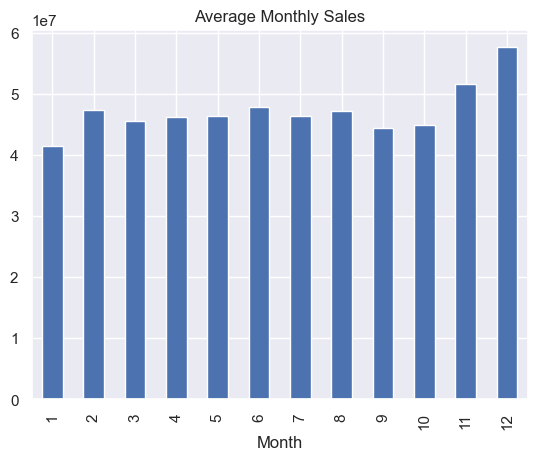

In [8]:
sales_data['Month'] = sales_data['Date'].dt.month

monthly_sales = sales_data.groupby('Month')['Weekly_Sales'].mean()

monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()

GROWTH RATE ANALYSIS

In [16]:
sales_data['Growth %'] = (
    sales_data['Weekly_Sales']
    .pct_change()
) * 100

fig = px.line(
    sales_data,
    x='Date',
    y='Growth %',
    title='Growth Rate %'
)

fig.show()

DAY-WISE SALES

In [17]:
sales_data['Day'] = (
    sales_data['Date']
    .dt.day_name()
)

fig = px.box(
    sales_data,
    x='Day',
    y='Weekly_Sales',
    title='Day-wise Sales Distribution'
)

fig.show()

 OUTLIER DETECTION

In [18]:
fig = px.box(
    sales_data,
    y='Weekly_Sales',
    title='Outlier Detection'
)

fig.show()

In [23]:
# ============================================
# DETECT SALES COLUMN
# ============================================

sales_col = next(
    (c for c in df.columns if 'sales' in c.lower()),
    None
)

print("Sales Column:", sales_col)

Sales Column: Weekly_Sales


PIE CHART ANALYSIS

In [24]:
store_col = next(
    (c for c in df.columns if 'store' in c.lower()),
    None
)

region_col = next(
    (c for c in df.columns if 'region' in c.lower()),
    None
)

category_col = next(
    (c for c in df.columns if 'category' in c.lower()),
    None
)

STORE CONTRIBUTION

In [25]:
# ============================================
# CELL : STORE CONTRIBUTION
# ============================================

if store_col:

    store_share = (
        df.groupby(store_col)[sales_col]
        .sum()
        .reset_index()
    )

    fig = px.pie(
        store_share,
        names=store_col,
        values=sales_col,
        title='Store Contribution'
    )

    fig.show()

CATEGORY-WISE SALES

In [27]:
if category_col:

    cat_sales = (
        df.groupby(category_col)[sales_col]
        .sum()
        .reset_index()
    )

    fig = px.bar(
        cat_sales,
        x=category_col,
        y=sales_col,
        title='Category-wise Sales'
    )

    fig.show()

REGION-WISE SALES

In [29]:
if region_col:

    reg_sales = (
        df.groupby(region_col)[sales_col]
        .sum()
        .reset_index()
    )

    fig = px.bar(
        reg_sales,
        x=region_col,
        y=sales_col,
        title='Region-wise Sales'
    )

    fig.show()

YEAR OVER YEAR GROWTH

In [ ]:


sales_data['Year'] = (
    sales_data['Date']
    .dt.year
)

yearly_sales = (
    sales_data.groupby('Year')['Weekly_Sales']
    .sum()
    .reset_index()
)

yearly_sales['YoY Growth %'] = (
    yearly_sales['Weekly_Sales']
    .pct_change()
) * 100

display(yearly_sales)

fig = px.bar(
    yearly_sales,
    x='Year',
    y='YoY Growth %',
    text_auto='.2f',
    title='Year-over-Year Growth %'
)

fig.show()

,Year,Weekly_Sales,YoY Growth %
0,2010,2.288886e+09,NaN
1,2011,2.448200e+09,6.960324
2,2012,2.000133e+09,-18.301901


CUMULATIVE SALES

In [31]:
sales_data['Cumulative Sales'] = (
    sales_data['Weekly_Sales']
    .cumsum()
)

fig = px.line(
    sales_data,
    x='Date',
    y='Cumulative Sales',
    title='Cumulative Sales Growth'
)

fig.show()

MONTHLY SEASONALITY

In [32]:
sales_data['Month'] = (
    sales_data['Date']
    .dt.month
)

monthly_avg = (
    sales_data.groupby('Month')['Weekly_Sales']
    .mean()
    .reset_index()
)

fig = px.bar(
    monthly_avg,
    x='Month',
    y='Weekly_Sales',
    title='Monthly Seasonality'
)

fig.show()

SCATTER ANALYSIS

In [34]:
fig = px.scatter(
    sales_data,
    x='Date',
    y='Weekly_Sales',
    title='Sales Distribution Over Time'
)

fig.show()

TOP 5 SALES DATES

In [37]:
top_5 = sales_data.nlargest(
    5,
    'Weekly_Sales'
)

fig = px.bar(
    top_5,
    x='Date',
    y='Weekly_Sales',
    text_auto=True,
    title='Top 5 Sales Dates'
)

fig.show()

 LOWEST 5 SALES DATES

In [38]:
bottom_5 = sales_data.nsmallest(
    5,
    'Weekly_Sales'
)

fig = px.bar(
    bottom_5,
    x='Date',
    y='Weekly_Sales',
    text_auto=True,
    title='Lowest 5 Sales Dates'
)

fig.show()

 MONTHLY GROWTH ANALYSIS

In [40]:
sales_data['Month_Name'] = (
    sales_data['Date']
    .dt.strftime('%b')
)

monthly_growth = (
    sales_data.groupby('Month_Name')['Growth %']
    .mean()
    .reset_index()
)

fig = px.line(
    monthly_growth,
    x='Month_Name',
    y='Growth %',
    markers=True,
    title='Monthly Growth Analysis'
)

fig.show()

SALES DISTRIBUTION

In [41]:
fig = px.histogram(
    sales_data,
    x='Weekly_Sales',
    nbins=25,
    title='Sales Frequency Distribution'
)

fig.show()

CORRELATION MATRIX

In [42]:
corr_matrix = sales_data[
    ['Weekly_Sales', 'Month', 'Year']
].corr()

display(corr_matrix)

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    title='Correlation Heatmap'
)

fig.show()

,Weekly_Sales,Month,Year
Weekly_Sales,1.000000,0.356419,-0.086023
Month,0.356419,1.000000,-0.194465
Year,-0.086023,-0.194465,1.000000


DATA QUALITY CHECK

In [43]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values
})

display(missing_df)

,Column,Missing Values
0,Store,0
1,Date,0
2,Weekly_Sales,0
3,Holiday_Flag,0
4,Temperature,0
5,Fuel_Price,0
6,CPI,0
7,Unemployment,0


Rolling Mean (Trend Smoothing)

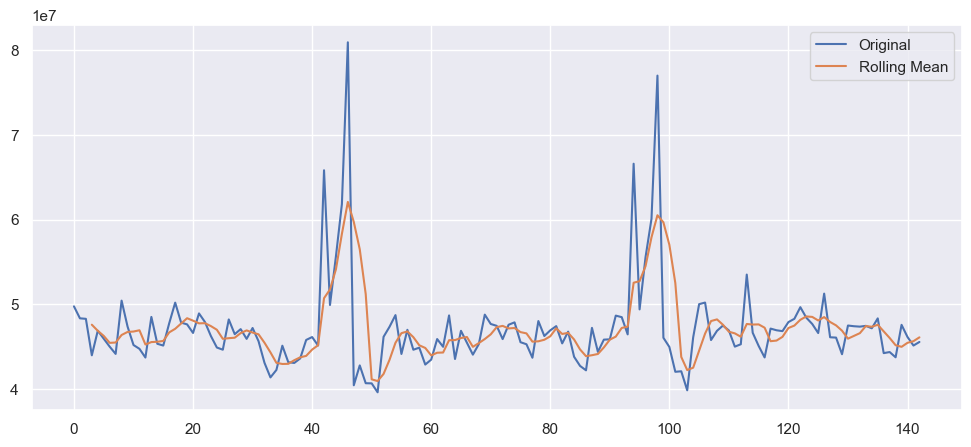

In [9]:
sales_data['Rolling_Mean'] = sales_data['Weekly_Sales'].rolling(window=4).mean()

plt.figure(figsize=(12,5))
plt.plot(sales_data['Weekly_Sales'], label='Original')
plt.plot(sales_data['Rolling_Mean'], label='Rolling Mean')
plt.legend()
plt.show()

Train-Test Split

In [10]:
train = sales_data.iloc[:int(0.8*len(sales_data))]
test = sales_data.iloc[int(0.8*len(sales_data)):]

ARIMA Model

In [11]:
model = ARIMA(train['Weekly_Sales'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1923.247
Date:                Thu, 28 May 2026   AIC                           3858.493
Time:                        12:39:37   BIC                           3874.858
Sample:                             0   HQIC                          3865.134
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2956      0.051     -5.829      0.000      -0.395      -0.196
ar.L2         -0.2007      0.059     -3.395      0.001      -0.317      -0.085
ar.L3         -0.1744      0.073     -2.400      0.0

Forecast

In [12]:
forecast = model_fit.forecast(steps=len(test))

# Convert to series
forecast = pd.Series(forecast, index=test.index)

Compare Actual vs Predicted

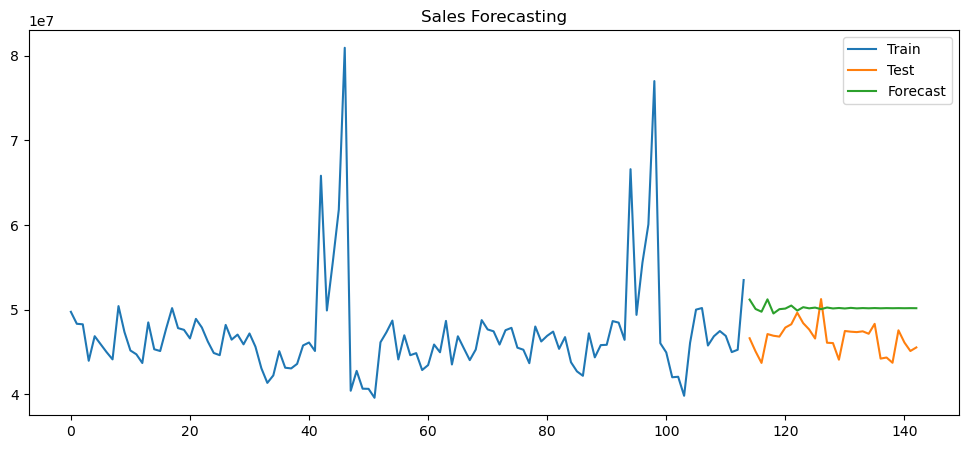

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train['Weekly_Sales'], label='Train')
plt.plot(test['Weekly_Sales'], label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("Sales Forecasting")
plt.show()

Model Evaluation

In [13]:
mae = mean_absolute_error(test['Weekly_Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3597509.8170959773
RMSE: 3924134.117677044


Future Forecast (Next 10 Weeks)

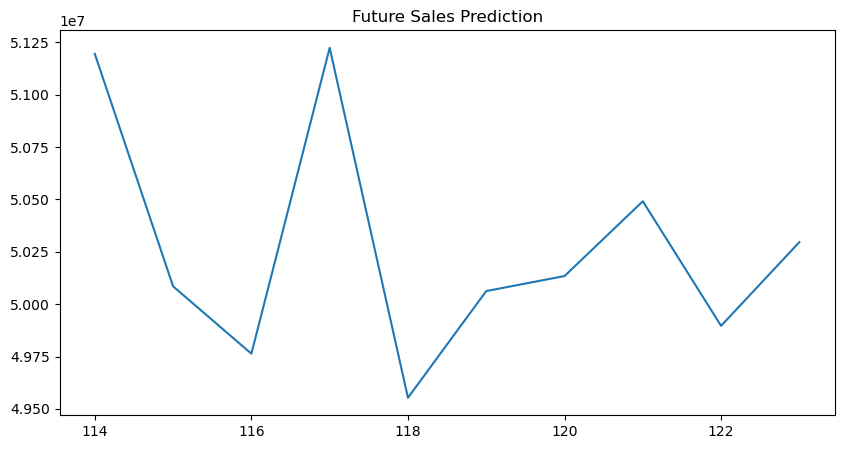

In [15]:
future_forecast = model_fit.forecast(steps=10)

plt.figure(figsize=(10,5))
plt.plot(future_forecast)
plt.title("Future Sales Prediction")
plt.show()

Prepare Data

In [16]:
# Extract time features
sales_data['Year'] = sales_data['Date'].dt.year
sales_data['Month'] = sales_data['Date'].dt.month
sales_data['Week'] = sales_data['Date'].dt.isocalendar().week

Line Plot of Sales by Year

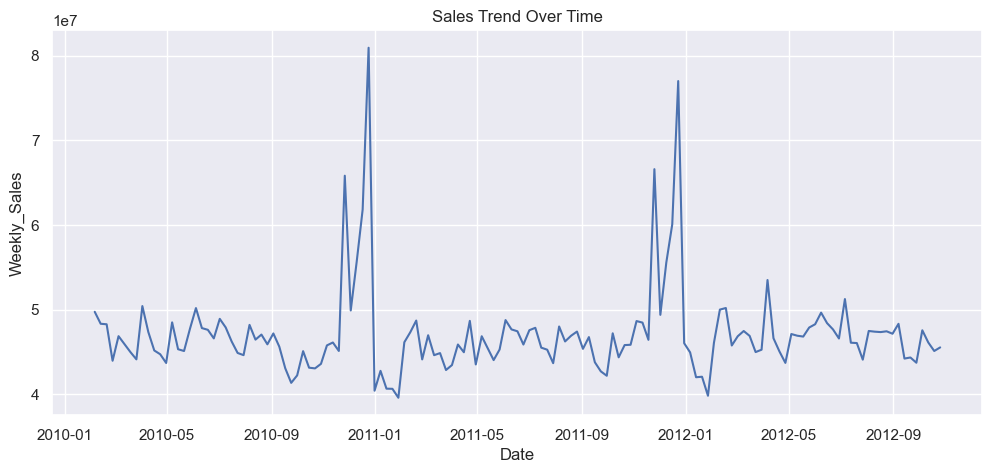

In [19]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Weekly_Sales', data=sales_data)
plt.title("Sales Trend Over Time")
plt.show()

Monthly Sales Distribution

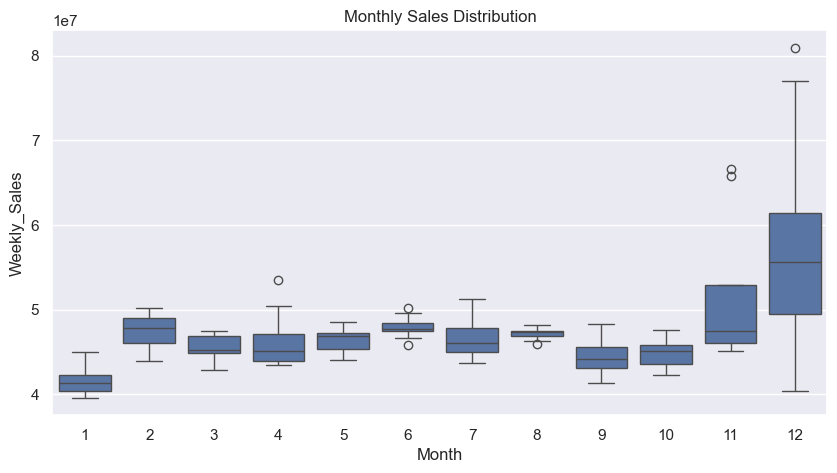

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Weekly_Sales', data=sales_data)
plt.title("Monthly Sales Distribution")
plt.show()

Sales Distribution

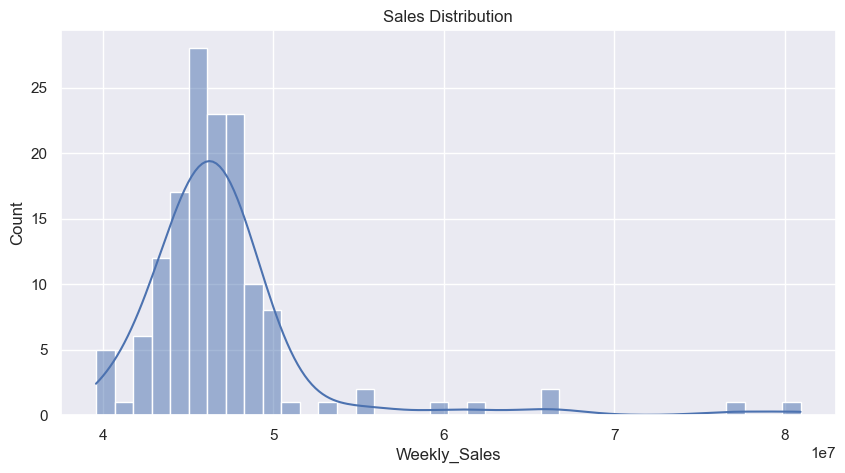

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(sales_data['Weekly_Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

Correlation Heatmap

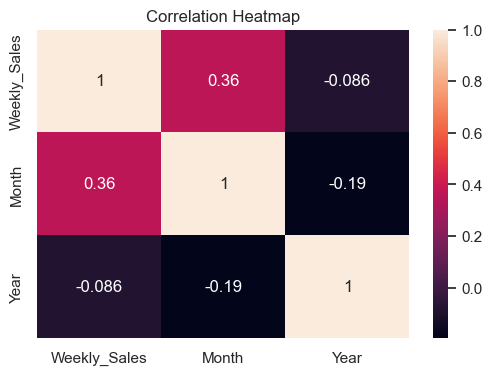

In [22]:
# Correlation matrix
corr = sales_data[['Weekly_Sales','Month','Year']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Pivot Heatmap (Month vs Year)

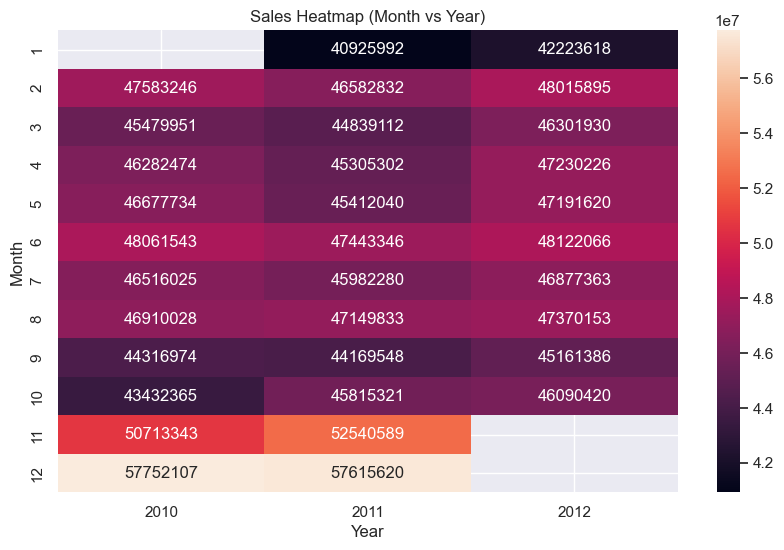

In [23]:
pivot_table = sales_data.pivot_table(
    values='Weekly_Sales',
    index='Month',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f")
plt.title("Sales Heatmap (Month vs Year)")
plt.show()

Pairplot

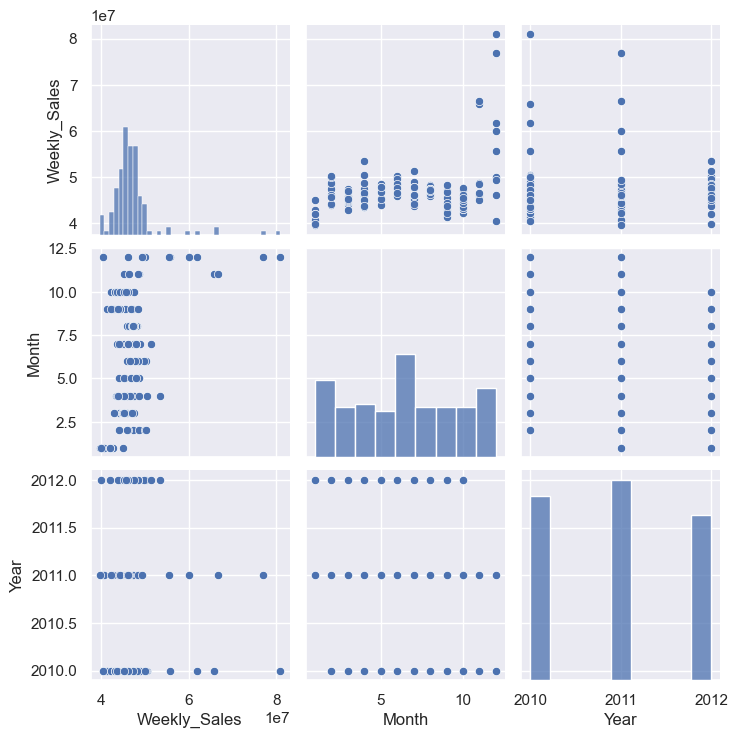

In [24]:
sns.pairplot(sales_data[['Weekly_Sales','Month','Year']])
plt.show()

Rolling Trend

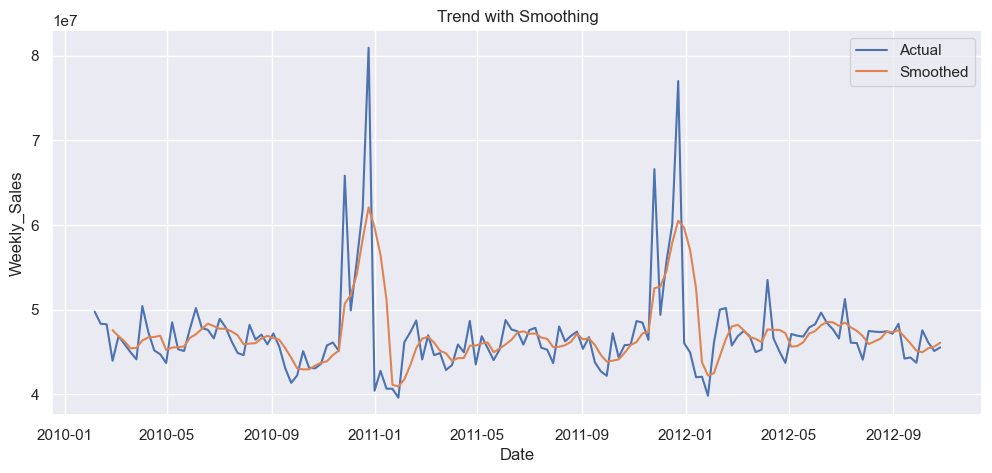

In [25]:
sales_data['Rolling'] = sales_data['Weekly_Sales'].rolling(4).mean()

plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='Weekly_Sales', data=sales_data, label='Actual')
sns.lineplot(x='Date', y='Rolling', data=sales_data, label='Smoothed')
plt.title("Trend with Smoothing")
plt.show()

SARIMA (Seasonal Forecasting)

1. Data Preparation (IMPORTANT)

In [51]:
# If Date exists → set index
if 'Date' in sales_data.columns:
    sales_data.set_index('Date', inplace=True)

# Ensure sorted
sales_data = sales_data.sort_index()

In [35]:
train = sales_data.iloc[:int(0.8*len(sales_data))]
test = sales_data.iloc[int(0.8*len(sales_data)):]

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Weekly_Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)   # 52 weeks seasonality
)

model_fit = model.fit()

print(model_fit.summary())

c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -970.926
Date:                            Thu, 28 May 2026   AIC                           1951.853
Time:                                    13:11:20   BIC                           1962.407
Sample:                                         0   HQIC                          1955.989
                                            - 114                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1615      1.209      0.134      0.894      -2.208       2.531
ma.L1         -0.2769      1.188   

In [52]:
forecast = model_fit.forecast(steps=len(test))

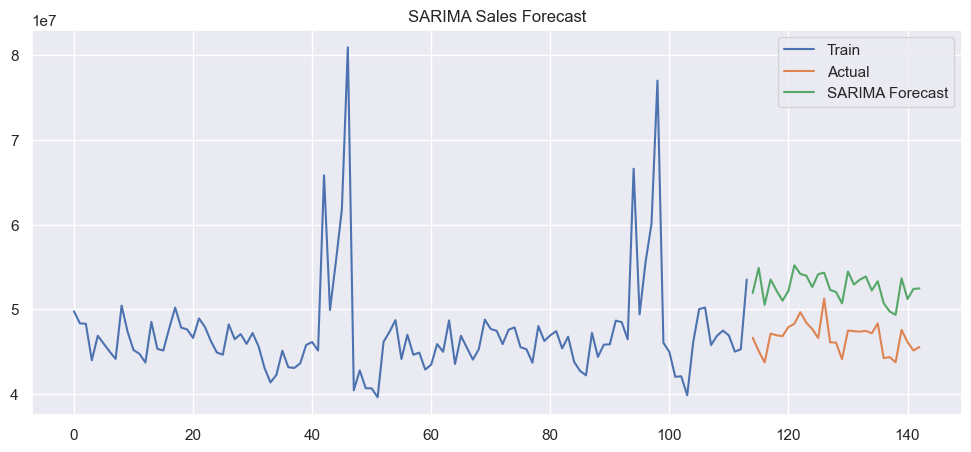

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train.index, train['Weekly_Sales'], label='Train')
plt.plot(test.index, test['Weekly_Sales'], label='Actual')
plt.plot(test.index, forecast, label='SARIMA Forecast')

plt.legend()
plt.title("SARIMA Sales Forecast")
plt.show()

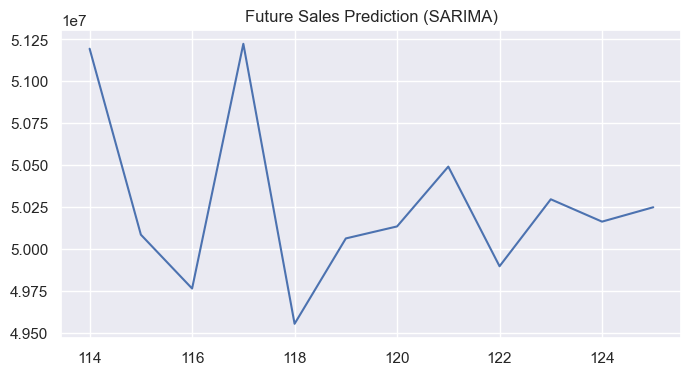

In [48]:
future = model_fit.forecast(steps=12)

plt.figure(figsize=(8,4))
plt.plot(future)
plt.title("Future Sales Prediction (SARIMA)")
plt.show()

1. Generate Forecast + Confidence Intervals

In [54]:
# Get forecast object
forecast_obj = model_fit.get_forecast(steps=len(test))

# Mean prediction
forecast = forecast_obj.predicted_mean

# Confidence intervals
conf_int = forecast_obj.conf_int()

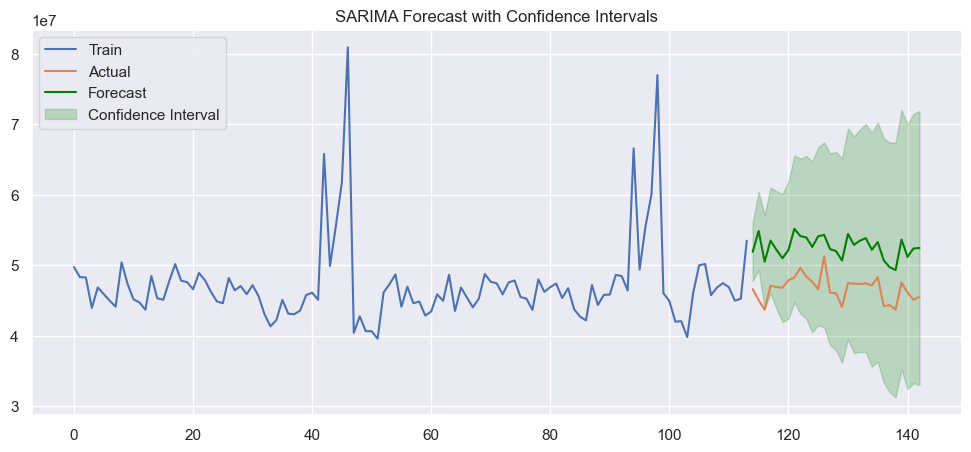

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot actual data
plt.plot(train.index, train['Weekly_Sales'], label='Train')
plt.plot(test.index, test['Weekly_Sales'], label='Actual')

# Plot forecast
plt.plot(test.index, forecast, label='Forecast', color='green')

# Plot confidence interval
plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='green',
    alpha=0.2,
    label='Confidence Interval'
)

plt.legend()
plt.title("SARIMA Forecast with Confidence Intervals")
plt.show()

FORECAST NEXT 1 YEAR

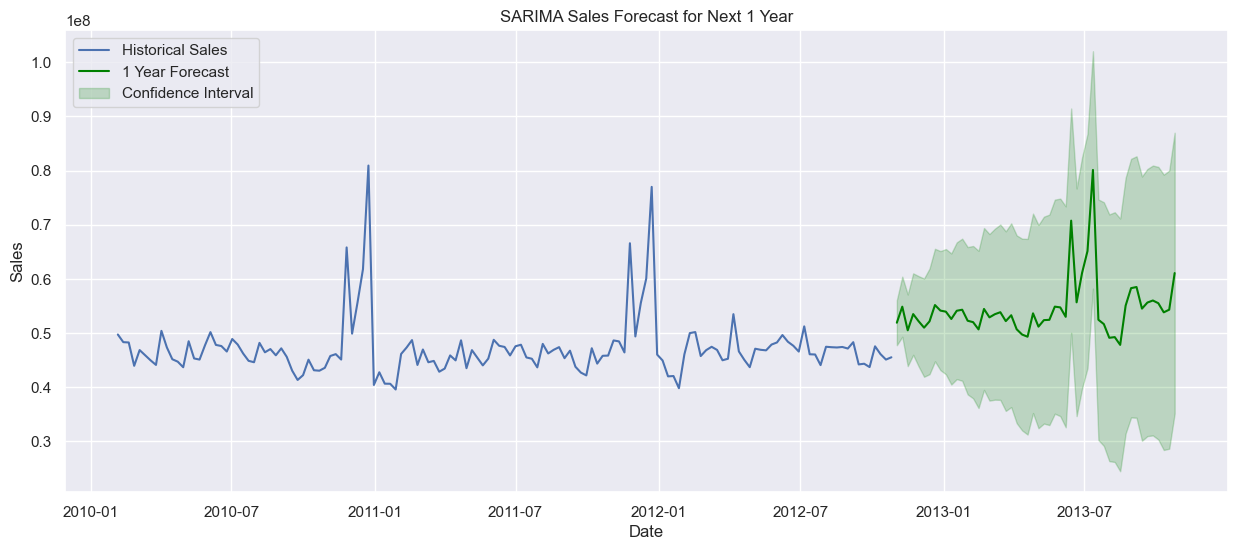

In [56]:
# ============================================
# SARIMA FORECAST FOR NEXT 1 YEAR
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# 52 weeks = 1 year forecast
future_steps = 52

# Generate forecast
future_forecast_obj = model_fit.get_forecast(
    steps=future_steps
)

# Forecast values
future_forecast = future_forecast_obj.predicted_mean

# Confidence intervals
future_conf_int = future_forecast_obj.conf_int()

# Create future weekly dates
future_dates = pd.date_range(
    start=sales_data.index[-1],
    periods=future_steps + 1,
    freq='W-FRI'
)[1:]

# ============================================
# PLOT FORECAST
# ============================================

plt.figure(figsize=(15,6))

# Historical Sales
plt.plot(
    sales_data.index,
    sales_data['Weekly_Sales'],
    label='Historical Sales'
)

# Forecasted Sales
plt.plot(
    future_dates,
    future_forecast,
    label='1 Year Forecast',
    color='green'
)

# Confidence Interval
plt.fill_between(
    future_dates,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    color='green',
    alpha=0.2,
    label='Confidence Interval'
)

# Labels
plt.title("SARIMA Sales Forecast for Next 1 Year")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()